# E9 - Spatio-temporal completion baselines and decomposition by sky condition

Through E7 the comparators were pure-temporal interpolation and a trained Transformer. Neither
represents the family of transductive spatio-temporal completion methods commonly used to fill gaps
in sensor networks. This notebook adds two members of that family. Both are training-free, so the
comparison requires no train/test split.

The first baseline is **low-rank matrix completion** by singular-value soft-thresholding. The second
is **graph-regularised matrix factorisation (GRMF)**, `Y ~ A Bᵀ`, with a graph Laplacian penalty on
the station factor and a second-difference penalty on the time factor. GRMF uses the same graph
matrix and the same temporal operator as STMAC.

We report three things. First, aggregate RMSE over all daytime cells. Second, RMSE split by the
daily clear-sky index, because on a desert network most daytime cells fall on clear days whose
diurnal envelope is easy to reproduce, while imbalance cost arises on variable days. Third, the cost
of choosing a rank, because both baselines expose a knob that must be set before the method runs
while STMAC runs with `alpha_t = 10` and `alpha_s = 1` held fixed across every experiment.

Each baseline is evaluated under two selection regimes. **CV** selects the configuration by
cross-validation on observed cells only, without touching the contents of the gap. **Oracle** selects
by minimising RMSE against the withheld true values inside the gap. STMAC is given a matching oracle
regime over `alpha_t` and `alpha_s` so the comparison is symmetric. Selection runs on a seed that is
disjoint from the evaluation seeds.

In [1]:
import os, sys, json, time, warnings
import numpy as np
import pandas as pd
from pathlib import Path
from scipy import stats
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
plt.rcParams.update({
    "font.size": 12, "axes.titlesize": 13, "axes.labelsize": 12,
    "xtick.labelsize": 11, "ytick.labelsize": 11, "legend.fontsize": 10.5,
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
})


def _locate(name, marker):
    for c in (Path.cwd() / name, Path.cwd().parent / name,
              Path.cwd() / "notebooks" / name, Path.cwd().parent / "notebooks" / name):
        if (c / marker).exists():
            return c.resolve()
    raise FileNotFoundError(f"{name}/{marker} not found")


DATA = _locate("data", "multistation_1999_cleaned.parquet")
ROOT = DATA.parent
RES = ROOT / "results"; RES.mkdir(exist_ok=True)
for p in (Path.cwd().resolve(), ROOT, ROOT / "notebooks"):
    if (p / "stmac_core.py").exists() and str(p) not in sys.path:
        sys.path.insert(0, str(p))

import stmac_core as sc
import stmac_scalable as ss
from st_baselines import softimpute, grmf

N_SEEDS  = 10        # evaluation seeds 0..N_SEEDS-1; masks match E7 at the same seed
SEL_SEED = 101       # configuration-selection seed, disjoint from evaluation
CV_FRAC  = 0.10      # share of observed cells hidden for cross-validation
ALPHA_T, ALPHA_S, N_ITER = 10.0, 1.0, 4
KT_CLEAR, KT_CLOUDY = 0.85, 0.70


def atomic_csv(frame, path):
    tmp = Path(str(path) + ".tmp"); frame.to_csv(tmp, index=False); os.replace(tmp, path)


print("DATA   :", DATA)
print("RESULTS:", RES)

DATA   : /Users/user/Desktop/Proyek lomba paper/Project KFUPM/Final 5/stmac-demo 2/notebooks/data
RESULTS: /Users/user/Desktop/Proyek lomba paper/Project KFUPM/Final 5/stmac-demo 2/notebooks/results


## 1. The eleven-station network

Loading follows E7 exactly: the same parquet, column order aligned to the key order in
`stations.json` so that Laplacian rows match their stations, and an evaluation window of 08:00 to
16:00.

In [2]:
multi = pd.read_parquet(DATA / "multistation_1999_cleaned.parquet")
STATIONS = json.load(open(DATA / "stations.json"))
CODES = list(STATIONS.keys())
multi = multi[CODES]

LAT = np.array([STATIONS[c]["lat"] for c in CODES], float)
LON = np.array([STATIONS[c]["lon"] for c in CODES], float)
U_ALL = multi.to_numpy().T.astype(float)
N, T = U_ALL.shape

DELTA = (LON - LON.mean()) / 15 * 60 / 5
L_G = np.load(DATA / "graph_L.npy")
L_TIME = sc.build_temporal_smoothness(T)
IDX = multi.index
DAYTIME = (IDX.hour.values >= 8) & (IDX.hour.values <= 16)

print(f"stations {N} | timestamps {T:,} | peak {U_ALL.max():.1f} W/m2")
print(f"daytime cells {DAYTIME.sum():,} ({DAYTIME.mean()*100:.1f}%)")

_m, _ = sc.build_block_mask(N, T, 864, 0.10, seed=0)
_ev = (~_m) & DAYTIME[None, :]
_a = sc.rmse(U_ALL, sc.stmac(U_ALL, _m, L_G, L_TIME, DELTA, N_ITER, ALPHA_T, ALPHA_S), _ev)
_b = sc.rmse(U_ALL, ss.stmac_scalable(U_ALL, _m, L_G, L_TIME, DELTA, N_ITER, ALPHA_T, ALPHA_S), _ev)
print(f"solver equivalence check, core vs scalable: {_a:.4f} vs {_b:.4f} W/m2 "
      f"(difference {abs(_a-_b):.2e})")

stations 11 | timestamps 101,805 | peak 1961.5 W/m2
daytime cells 38,730 (38.0%)
solver equivalence check, core vs scalable: 202.0825 vs 202.0825 W/m2 (difference 0.00e+00)


## 2. Daily clear-sky index per station

The clear-sky curve has to be aligned with the record's clock. The 1999 NLR parquet is stored in
Saudi local time, not UTC, so the offset is recovered from the diurnal cycle itself rather than
assumed. The share of instantaneous clear-sky-index values pinned at the clipping bounds is printed
as a check: a large share means the curve and the data are misaligned.

Evaluation cells are split into clear days (`kt > 0.85`) and cloudy days (`kt < 0.70`) from a daily
aggregate, which is far more stable than an instantaneous ratio at low sun angles.

In [3]:
import sky_tools as sk

UTC_OFFSET, _est = sk.detect_utc_offset(IDX, U_ALL, LON)
print(f"detected clock offset of this record: UTC{UTC_OFFSET:+.1f} "
      f"(per-station estimates {_est.min():+.2f} to {_est.max():+.2f} h)")

COSZ, CS = sk.clear_sky_field(IDX, LAT, LON, UTC_OFFSET)
KT = sk.daily_clear_sky_index(IDX, U_ALL, CS, DAYTIME)
CLEAR, CLOUDY = sk.sky_masks(KT, KT_CLEAR, KT_CLOUDY)

_kt, _lo, _hi = sk.instantaneous_kt(U_ALL, CS, np.ones_like(U_ALL, bool) & DAYTIME[None, :])
print(f"instantaneous clear-sky index: mean {_kt.mean():.3f}, sd {_kt.std():.3f}, "
      f"pinned at the bounds {_lo*100:.1f}% low and {_hi*100:.1f}% high")

PC_CLEAR = float(np.nanmean(CLEAR[:, DAYTIME]) * 100)
PC_CLOUDY = float(np.nanmean(CLOUDY[:, DAYTIME]) * 100)
print(f"daytime cells on clear days {PC_CLEAR:5.1f}%, cloudy days {PC_CLOUDY:5.1f}%, "
      f"intermediate {100 - PC_CLEAR - PC_CLOUDY:5.1f}%")
print("Aggregate RMSE is dominated by clear days; the split is reported separately.")

detected clock offset of this record: UTC+3.0 (per-station estimates +2.82 to +3.19 h)
instantaneous clear-sky index: mean 0.887, sd 0.250, pinned at the bounds 0.0% low and 2.5% high
daytime cells on clear days  74.5%, cloudy days  11.5%, intermediate  14.0%
Aggregate RMSE is dominated by clear days; the split is reported separately.


## 3. Configuration space and the two selection criteria

The CV criterion hides a further 10 percent of the observed cells at random, fits on what remains,
and scores on the hidden cells. The contents of the block gap are never seen. The oracle criterion
fits on the block mask as given and scores directly against the withheld values inside the gap.

One structural property is worth stating before the results appear: the cells hidden for CV are
scattered at random whereas the gap to be reconstructed is block-shaped, so a configuration optimal
for one regime need not be optimal for the other.

In [4]:
SI_GRID = [dict(rank=r, lam=l) for r in (1, 2, 3, 4, 6) for l in (0.0, 200.0, 1000.0, 5000.0)]
GR_GRID = [dict(rank=r, lam_s=s, lam_t=t) for r in (1, 2, 3, 4)
           for s in (0.1, 1.0, 10.0) for t in (10.0, 1000.0)]
ST_GRID = [dict(alpha_t=a, alpha_s=b) for a in (1.0, 10.0, 100.0) for b in (0.1, 1.0, 10.0)]

FIT = {
    "softimpute": lambda Y, m, cfg: softimpute(Y, m, **cfg),
    "grmf":       lambda Y, m, cfg: grmf(Y, m, L_G, L_TIME, **cfg),
    "stmac":      lambda Y, m, cfg: ss.stmac_scalable(Y, m, L_G, L_TIME, DELTA, N_ITER,
                                                      cfg["alpha_t"], cfg["alpha_s"]),
}
GRIDS = {"softimpute": SI_GRID, "grmf": GR_GRID, "stmac": ST_GRID}


def cv_mask(mask, frac, seed):
    rng = np.random.default_rng(seed)
    hide = (rng.random(mask.shape) < frac) & mask
    return mask & ~hide, hide


def select_config(method, block_len, criterion, seed=SEL_SEED):
    mask, _ = sc.build_block_mask(N, T, block_len, 0.10, seed=seed)
    if criterion == "oracle":
        fit_mask, score_cells = mask, (~mask) & DAYTIME[None, :]
    else:
        fit_mask, hidden = cv_mask(mask, CV_FRAC, seed + 7919)
        score_cells = hidden & DAYTIME[None, :]
    Y = np.where(fit_mask, U_ALL, 0.0)
    best = None
    for cfg in GRIDS[method]:
        r = sc.rmse(U_ALL, FIT[method](Y, fit_mask, cfg), score_cells)
        if best is None or r < best[0]:
            best = (r, cfg)
    return best[1], best[0]


SEL_OUT = RES / "E9_selected_configs.csv"
if SEL_OUT.exists():
    SEL = pd.read_csv(SEL_OUT); SEL["config"] = SEL["config"].apply(json.loads)
else:
    recs, t0 = [], time.time()
    for method in ("softimpute", "grmf", "stmac"):
        for block_len, label in sc.BLOCK_SPECS:
            for crit in ("cv", "oracle"):
                cfg, score = select_config(method, block_len, crit)
                recs.append({"method": method, "block_len": block_len, "label": label,
                             "criterion": crit, "config": cfg, "selection_rmse": score})
                print(f"{method:11s} {label:>7s} {crit:6s} -> {cfg} "
                      f"({score:7.1f} W/m2, {(time.time()-t0)/60:5.1f} min)", flush=True)
    SEL = pd.DataFrame(recs)
    out = SEL.copy(); out["config"] = out["config"].apply(json.dumps)
    atomic_csv(out, SEL_OUT)

agree = []
for bl, lab in sc.BLOCK_SPECS:
    for method in ("softimpute", "grmf"):
        c = SEL[(SEL.method == method) & (SEL.block_len == bl)]
        cv = c[c.criterion == "cv"].iloc[0]["config"]
        orc = c[c.criterion == "oracle"].iloc[0]["config"]
        agree.append({"method": method, "label": lab, "cv": cv, "oracle": orc,
                      "same_rank": cv.get("rank") == orc.get("rank")})
AGR = pd.DataFrame(agree)
print()
print(AGR.to_string(index=False))
print(f"\nCV-selected rank equals the oracle rank in {int(AGR.same_rank.sum())} of {len(AGR)} cases.")


    method  label                                          cv                                      oracle  same_rank
softimpute 30 min                  {'rank': 1, 'lam': 1000.0}                  {'rank': 1, 'lam': 1000.0}       True
      grmf 30 min {'rank': 4, 'lam_s': 10.0, 'lam_t': 1000.0}  {'rank': 1, 'lam_s': 0.1, 'lam_t': 1000.0}      False
softimpute    2 h                  {'rank': 1, 'lam': 1000.0}                  {'rank': 1, 'lam': 5000.0}       True
      grmf    2 h {'rank': 4, 'lam_s': 10.0, 'lam_t': 1000.0}  {'rank': 1, 'lam_s': 0.1, 'lam_t': 1000.0}      False
softimpute    6 h                  {'rank': 1, 'lam': 1000.0}                  {'rank': 1, 'lam': 5000.0}       True
      grmf    6 h {'rank': 4, 'lam_s': 10.0, 'lam_t': 1000.0} {'rank': 1, 'lam_s': 10.0, 'lam_t': 1000.0}      False
softimpute   12 h                  {'rank': 1, 'lam': 1000.0}                     {'rank': 1, 'lam': 0.0}       True
      grmf   12 h {'rank': 4, 'lam_s': 10.0, 'lam_t': 1000.0} {

## 4. Block-length sweep

Six conditions run on identical masks, seed by seed, so every comparison is paired. Each row records
aggregate RMSE together with RMSE split by sky condition. Rows are written with atomic replacement so
an interrupted run can be resumed.

In [5]:
CONDITIONS = [
    ("stmac_fixed",       "stmac",      None),
    ("stmac_oracle",      "stmac",      "oracle"),
    ("softimpute_cv",     "softimpute", "cv"),
    ("softimpute_oracle", "softimpute", "oracle"),
    ("grmf_cv",           "grmf",       "cv"),
    ("grmf_oracle",       "grmf",       "oracle"),
]
NAMES = [n for n, _, _ in CONDITIONS]
LABEL = {"stmac_fixed": "STMAC (fixed alpha)", "stmac_oracle": "STMAC (oracle)",
         "softimpute_cv": "Low-rank (CV)", "softimpute_oracle": "Low-rank (oracle)",
         "grmf_cv": "Graph-reg. MF (CV)", "grmf_oracle": "Graph-reg. MF (oracle)"}


def config_for(method, criterion, block_len):
    if criterion is None:
        return dict(alpha_t=ALPHA_T, alpha_s=ALPHA_S)
    row = SEL[(SEL.method == method) & (SEL.criterion == criterion)
              & (SEL.block_len == block_len)].iloc[0]
    return dict(row["config"])


SWEEP = RES / "E9_raw.csv"
rows = pd.read_csv(SWEEP).to_dict("records") if SWEEP.exists() else []
done = {(r["seed"], r["block_len"]) for r in rows}
t_start = time.time()

for seed in range(N_SEEDS):
    for block_len, label in sc.BLOCK_SPECS:
        if (seed, block_len) in done:
            continue
        mask, n_blk = sc.build_block_mask(N, T, block_len, 0.10, seed=seed)
        ev = (~mask) & DAYTIME[None, :]
        ev_clear, ev_cloudy = ev & CLEAR, ev & CLOUDY
        Y = np.where(mask, U_ALL, 0.0)
        rec = {"seed": seed, "block_len": block_len, "block_label": label, "n_blocks": n_blk,
               "n_eval": int(ev.sum()), "n_clear": int(ev_clear.sum()),
               "n_cloudy": int(ev_cloudy.sum())}
        for name, method, crit in CONDITIONS:
            t0 = time.time()
            X = FIT[method](Y, mask, config_for(method, crit, block_len))
            rec["rmse_" + name] = sc.rmse(U_ALL, X, ev)
            rec["clear_" + name] = sc.rmse(U_ALL, X, ev_clear)
            rec["cloudy_" + name] = sc.rmse(U_ALL, X, ev_cloudy)
            rec["sec_" + name] = time.time() - t0
        rows.append(rec)
        atomic_csv(pd.DataFrame(rows), SWEEP)
        print(f"seed={seed:2d} {label:>7s} | aggregate " +
              " ".join(f"{n[:6]}={rec['rmse_'+n]:6.1f}" for n in NAMES[:4]) +
              f" | cloudy STMAC={rec['cloudy_stmac_fixed']:6.1f} "
              f"LR={rec['cloudy_softimpute_cv']:6.1f} | {(time.time()-t_start)/60:5.1f} min",
              flush=True)

E9 = pd.DataFrame(rows)
print(f"\ndone: {len(E9)} rows in {(time.time()-t_start)/60:.1f} min")

seed= 0  30 min | aggregate stmac_= 196.1 stmac_= 191.1 softim= 191.1 softim= 191.1 | cloudy STMAC= 323.8 LR= 326.0 |   0.8 min
seed= 0     2 h | aggregate stmac_= 190.5 stmac_= 186.8 softim= 188.7 softim= 188.5 | cloudy STMAC= 314.2 LR= 319.6 |   1.9 min
seed= 0     6 h | aggregate stmac_= 186.6 stmac_= 181.5 softim= 185.8 softim= 185.6 | cloudy STMAC= 320.0 LR= 322.0 |   2.7 min
seed= 0    12 h | aggregate stmac_= 187.7 stmac_= 184.8 softim= 188.4 softim= 188.4 | cloudy STMAC= 288.9 LR= 304.2 |   3.6 min
seed= 0   1 day | aggregate stmac_= 199.7 stmac_= 195.7 softim= 200.8 softim= 200.9 | cloudy STMAC= 333.5 LR= 337.6 |   4.5 min
seed= 0   3 day | aggregate stmac_= 202.1 stmac_= 195.4 softim= 192.0 softim= 191.9 | cloudy STMAC= 331.2 LR= 326.0 |   5.4 min
seed= 0   7 day | aggregate stmac_= 182.8 stmac_= 173.6 softim= 179.9 softim= 179.1 | cloudy STMAC= 324.7 LR= 332.7 |   6.4 min
seed= 1  30 min | aggregate stmac_= 197.3 stmac_= 191.2 softim= 192.4 softim= 192.4 | cloudy STMAC= 336.

## 5. Rank sensitivity of low-rank completion

A separate sweep measures the cost of choosing the wrong rank, with the STMAC error drawn as a flat
reference because STMAC exposes no equivalent knob.

In [6]:
RANK_OUT = RES / "E9_rank_sensitivity.csv"
if RANK_OUT.exists():
    RANKS = pd.read_csv(RANK_OUT)
else:
    recs = []
    for seed in range(min(3, N_SEEDS)):
        for block_len, label in [(72, "6 h"), (864, "3 day"), (2016, "7 day")]:
            mask, _ = sc.build_block_mask(N, T, block_len, 0.10, seed=seed)
            ev = (~mask) & DAYTIME[None, :]
            Y = np.where(mask, U_ALL, 0.0)
            st = sc.rmse(U_ALL, ss.stmac_scalable(Y, mask, L_G, L_TIME, DELTA,
                                                  N_ITER, ALPHA_T, ALPHA_S), ev)
            for rank in range(1, N + 1):
                recs.append({"seed": seed, "block_len": block_len, "label": label, "rank": rank,
                             "rmse_softimpute": sc.rmse(U_ALL, softimpute(Y, mask, rank, 200.0), ev),
                             "rmse_stmac": st})
            print(f"seed={seed} {label:>7s} done", flush=True)
    RANKS = pd.DataFrame(recs)
    atomic_csv(RANKS, RANK_OUT)

print(RANKS.groupby(["label", "rank"], sort=False).rmse_softimpute.mean()
      .unstack(0).round(1).to_string())

label    6 h  3 day  7 day
rank                      
1      188.2  189.4  181.6
2      239.9  236.0  267.4
3      283.0  307.0  303.1
4      308.5  343.7  377.8
5      358.9  388.9  393.7
6      394.6  428.8  405.0
7      386.9  429.1  420.3
8      385.5  406.0  420.3
9      410.0  413.5  409.4
10     398.9  395.4  404.8
11     377.7  390.9  371.4


## 6. Confidence intervals and paired tests

The statistical frame matches E7. Tests run twice, once on the aggregate and once on cloudy-day
cells, with Holm correction inside each family.

In [7]:
def ci95(x):
    x = np.asarray(x, float); m = x.mean()
    h = x.std(ddof=1) / np.sqrt(len(x)) * stats.t.ppf(0.975, len(x) - 1)
    return m, m - h, m + h

def holm(p):
    p = np.asarray(p, float); order = np.argsort(p); k = len(p)
    adj = np.empty(k); run = 0.0
    for i, idx in enumerate(order):
        run = max(run, (k - i) * p[idx]); adj[idx] = min(run, 1.0)
    return adj

frames = {}
for tag, pre in [("all", "rmse_"), ("cloudy", "cloudy_"), ("clear", "clear_")]:
    summ = []
    for bl, lab in sc.BLOCK_SPECS:
        g = E9[E9.block_len == bl]
        row = {"block_len": bl, "label": lab, "n": len(g)}
        for n in NAMES:
            mu, lo, hi = ci95(g[pre + n])
            row[n], row[n + "_lo"], row[n + "_hi"] = mu, lo, hi
        summ.append(row)
    frames[tag] = pd.DataFrame(summ)
    atomic_csv(frames[tag], RES / f"E9_summary_{tag}.csv")

tests = []
for tag, pre in [("all", "rmse_"), ("cloudy", "cloudy_")]:
    for comp in NAMES[1:]:
        hold, praw = [], []
        for bl, lab in sc.BLOCK_SPECS:
            g = E9[E9.block_len == bl]
            d = g[pre + comp].to_numpy(float) - g[pre + "stmac_fixed"].to_numpy(float)
            try:
                p = stats.wilcoxon(g[pre + comp], g[pre + "stmac_fixed"]).pvalue
            except ValueError:
                p = 1.0
            mu, lo, hi = ci95(d)
            hold.append({"subset": tag, "comparison": f"{comp} vs stmac_fixed", "label": lab,
                         "mean_diff": mu, "ci_lo": lo, "ci_hi": hi,
                         "wins_stmac": int((d > 0).sum()), "n": len(d)})
            praw.append(p)
        for r_, p_, ph in zip(hold, praw, holm(praw)):
            r_["p_wilcoxon"], r_["p_holm"] = p_, ph
        tests += hold
TST = pd.DataFrame(tests)
atomic_csv(TST, RES / "E9_paired_tests.csv")

growth = []
for n in NAMES:
    per = []
    for s in sorted(E9.seed.unique()):
        g = E9[E9.seed == s].set_index("block_len")["rmse_" + n]
        if 6 in g.index and 2016 in g.index:
            per.append(g.loc[2016] / g.loc[6])
    mu, lo, hi = ci95(per)
    growth.append({"condition": n, "growth": mu, "ci_lo": lo, "ci_hi": hi})
GRW = pd.DataFrame(growth); atomic_csv(GRW, RES / "E9_growth.csv")

print("AGGREGATE")
print(frames["all"][["label"] + NAMES].to_string(index=False, float_format=lambda v: f"{v:8.1f}"))
print("\nCLOUDY DAYS")
print(frames["cloudy"][["label"] + NAMES].to_string(index=False, float_format=lambda v: f"{v:8.1f}"))

AGGREGATE
 label  stmac_fixed  stmac_oracle  softimpute_cv  softimpute_oracle  grmf_cv  grmf_oracle
30 min        196.0         190.4          191.5              191.5    198.0        189.7
   2 h        196.7         191.3          191.5              191.5    314.2        190.9
   6 h        192.3         187.7          189.8              189.7    370.1        189.4
  12 h        195.1         189.9          190.8              190.8    477.0        190.4
 1 day        193.3         188.0          190.6              190.7    583.8        190.4
 3 day        197.9         191.5          191.1              191.1    536.1        190.8
 7 day        193.9         188.5          191.4              191.3    569.1        191.1

CLOUDY DAYS
 label  stmac_fixed  stmac_oracle  softimpute_cv  softimpute_oracle  grmf_cv  grmf_oracle
30 min        333.0         332.6          331.9              331.9    306.7        330.7
   2 h        334.6         336.5          336.0              330.2    465.2 

## 7. Figure

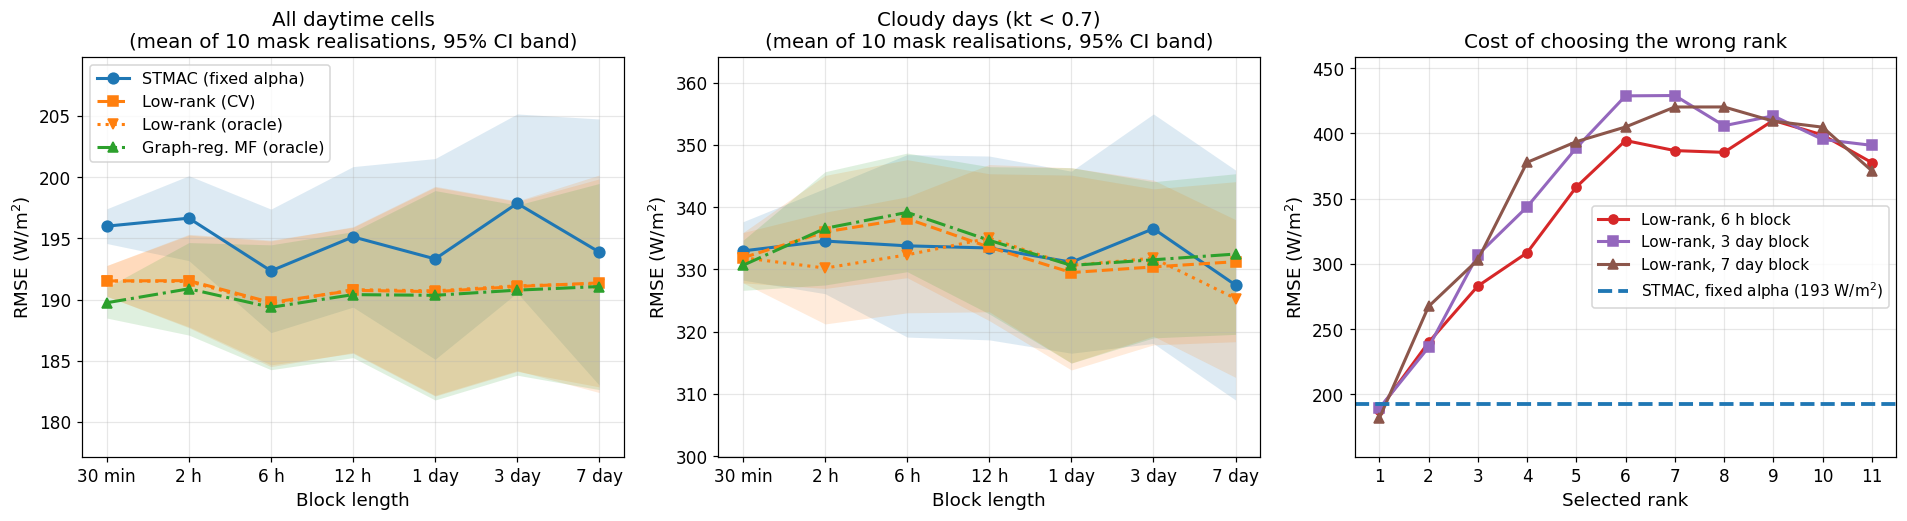

In [8]:
SHOW = ["stmac_fixed", "softimpute_cv", "softimpute_oracle", "grmf_oracle"]
STYLE = {"stmac_fixed": ("C0", "o", "-"), "softimpute_cv": ("C1", "s", "--"),
         "softimpute_oracle": ("C1", "v", ":"), "grmf_oracle": ("C2", "^", "-.")}
x = np.arange(len(sc.BLOCK_SPECS))
labels = [l for _, l in sc.BLOCK_SPECS]

fig, ax = plt.subplots(1, 3, figsize=(17.5, 4.9))
for k, (tag, title) in enumerate([("all", "All daytime cells"),
                                  ("cloudy", f"Cloudy days (kt < {KT_CLOUDY})")]):
    S_ = frames[tag]
    for n in SHOW:
        c, mk, ls = STYLE[n]
        ax[k].plot(x, S_[n], ls, color=c, marker=mk, lw=2, ms=7, label=LABEL[n])
        ax[k].fill_between(x, S_[n + "_lo"], S_[n + "_hi"], color=c, alpha=0.15, lw=0)
    ax[k].set_xticks(x); ax[k].set_xticklabels(labels)
    ax[k].set_xlabel("Block length"); ax[k].set_ylabel(r"RMSE (W/m$^2$)")
    ax[k].set_title(f"{title}\n(mean of {N_SEEDS} mask realisations, 95% CI band)")
    ax[k].grid(alpha=0.3); ax[k].margins(y=0.20)
ax[0].legend(frameon=True, loc="best")

for lab, c, mk in [("6 h", "C3", "o"), ("3 day", "C4", "s"), ("7 day", "C5", "^")]:
    g = RANKS[RANKS.label == lab].groupby("rank").rmse_softimpute.mean()
    ax[2].plot(g.index, g.values, "-", color=c, marker=mk, lw=2, ms=6,
               label=f"Low-rank, {lab} block")
st_line = RANKS.groupby("label").rmse_stmac.mean().mean()
ax[2].axhline(st_line, color="C0", lw=2.5, ls="--",
              label=f"STMAC, fixed alpha ({st_line:.0f} W/m$^2$)")
ax[2].set_xlabel("Selected rank"); ax[2].set_ylabel(r"RMSE (W/m$^2$)")
ax[2].set_title("Cost of choosing the wrong rank"); ax[2].set_xticks(range(1, N + 1))
ax[2].legend(frameon=True, fontsize=10); ax[2].grid(alpha=0.3); ax[2].margins(y=0.12)

fig.tight_layout()
fig.savefig(RES / "E9_baselines_skyclass_rankcost.png")
plt.show()

## 8. Automatic readout

The block below assembles final statements directly from the result files.

In [10]:
SA = pd.read_csv(RES / "E9_summary_all.csv")
SC_ = pd.read_csv(RES / "E9_summary_cloudy.csv")
SCL = pd.read_csv(RES / "E9_summary_clear.csv")
TT = pd.read_csv(RES / "E9_paired_tests.csv")
G = pd.read_csv(RES / "E9_growth.csv")
RK = pd.read_csv(RES / "E9_rank_sensitivity.csv")

print("SUMMARY")
print("=" * 82)

print("1. Composition of evaluation cells")
print(f"   Clear days  {E9.n_clear.sum() / E9.n_eval.sum() * 100:5.1f}% of evaluated cells")
print(f"   Cloudy days {E9.n_cloudy.sum() / E9.n_eval.sum() * 100:5.1f}%")

print("\n2. Selected configurations")
for method in ("softimpute", "grmf"):
    for crit in ("cv", "oracle"):
        cfgs = SEL[(SEL.method == method) & (SEL.criterion == crit)]["config"].tolist()
        ranks = sorted({c.get("rank") for c in cfgs})
        print(f"   {method:11s} {crit:6s}: selected ranks {ranks}")
print(f"   CV rank matches oracle rank in {int(AGR.same_rank.sum())}/{len(AGR)} cases.")

print("\n3. Aggregate over all daytime cells")
for comp in NAMES[1:]:
    s = TT[(TT.subset == "all") & TT.comparison.str.startswith(comp)]
    w = s[s.mean_diff > 0]; l = s[s.mean_diff < 0]
    print(f"   {LABEL[comp]:24s} STMAC leads {len(w)}/{len(s)} (significant {(w.p_holm<0.05).sum()}), "
          f"trails {len(l)}/{len(s)} (significant {(l.p_holm<0.05).sum()})")

print("\n4. Cloudy days")
for comp in NAMES[1:]:
    s = TT[(TT.subset == "cloudy") & TT.comparison.str.startswith(comp)]
    w = s[s.mean_diff > 0]; l = s[s.mean_diff < 0]
    print(f"   {LABEL[comp]:24s} STMAC leads {len(w)}/{len(s)} (significant {(w.p_holm<0.05).sum()}), "
          f"trails {len(l)}/{len(s)} (significant {(l.p_holm<0.05).sum()})")
    if len(w):
        print(f"      margin when leading {w.mean_diff.min():.1f} to {w.mean_diff.max():.1f} W/m2")

print("\n5. STMAC against low-rank CV, split by sky condition")
for tag, F in [("all cells", SA), ("clear days", SCL), ("cloudy days", SC_)]:
    d = (F.softimpute_cv - F.stmac_fixed)
    print(f"   {tag:11s}: STMAC {F.stmac_fixed.mean():6.1f} W/m2, low-rank {F.softimpute_cv.mean():6.1f}, "
          f"difference {d.mean():+6.1f} (positive means STMAC leads)")

print("\n6. Cost of choosing the wrong rank")
for lab in RK.label.unique():
    g = RK[RK.label == lab].groupby("rank").rmse_softimpute.mean()
    b = int(g.idxmin())
    print(f"   {lab:>6s} block: optimum at rank {b} ({g.min():.1f} W/m2), rank {b+1} gives "
          f"{g.loc[b+1]:.1f}, full range across ranks {g.min():.1f}-{g.max():.1f} W/m2")
print(f"   STMAC with fixed alpha sits at {RK.groupby('label').rmse_stmac.mean().mean():.1f} W/m2 "
      f"with no selection step.")

print("\n7. Error growth from the 30-minute to the 7-day block")
for _, r in G.iterrows():
    print(f"   {LABEL[r.condition]:24s} {r.growth:5.2f}x [{r.ci_lo:.2f}, {r.ci_hi:.2f}]")

print("\n8. Mean wall-clock cost per reconstruction")
for n in NAMES:
    print(f"   {LABEL[n]:24s} {E9['sec_' + n].mean():6.1f} s")

print("\n9. Conclusion")
cl = TT[(TT.subset == "cloudy") & TT.comparison.str.startswith("softimpute_cv")]
clw = cl[cl.mean_diff > 0]
frac_cloudy = E9.n_cloudy.sum() / E9.n_eval.sum() * 100
frac_clear = E9.n_clear.sum() / E9.n_eval.sum() * 100
print("   \"Two training-free spatio-temporal completion baselines were run on identical masks:")
print("    low-rank matrix completion and graph-regularised matrix factorisation. On the 1999")
print(f"    network, {(SA.softimpute_cv < SA.stmac_fixed).sum()} of {len(SA)} block lengths favour low-rank completion in aggregate RMSE.")
print(f"    The aggregate is dominated by clear days, which supply {frac_clear:.0f} percent of evaluated cells")
print("    and whose diurnal envelope a single global factor already reproduces. Restricted to days")
print(f"    with a clear-sky index below {KT_CLOUDY}, STMAC leads at {len(clw)} of {len(cl)} block lengths by {clw.mean_diff.min():.0f} to")
rk3 = RK[RK.label == '3 day'].groupby('rank').rmse_softimpute.mean()
print(f"    {clw.mean_diff.max():.0f} W/m2. Low-rank completion also requires a rank to be fixed in advance: at a")
print(f"    three-day block the same method spans {rk3.min():.0f} to {rk3.max():.0f} W/m2 across ranks 1 to {int(rk3.index.max())}, whereas")
print("    STMAC uses the alpha values held fixed throughout this paper.\"")

SUMMARY
1. Composition of evaluation cells
   Clear days   74.5% of evaluated cells
   Cloudy days  11.7%

2. Selected configurations
   softimpute  cv    : selected ranks [1]
   softimpute  oracle: selected ranks [1]
   grmf        cv    : selected ranks [4]
   grmf        oracle: selected ranks [1]
   CV rank matches oracle rank in 7/14 cases.

3. Aggregate over all daytime cells
   STMAC (oracle)           STMAC leads 0/7 (significant 0), trails 7/7 (significant 7)
   Low-rank (CV)            STMAC leads 0/7 (significant 0), trails 7/7 (significant 3)
   Low-rank (oracle)        STMAC leads 0/7 (significant 0), trails 7/7 (significant 3)
   Graph-reg. MF (CV)       STMAC leads 7/7 (significant 6), trails 0/7 (significant 0)
   Graph-reg. MF (oracle)   STMAC leads 0/7 (significant 0), trails 7/7 (significant 4)

4. Cloudy days
   STMAC (oracle)           STMAC leads 4/7 (significant 0), trails 3/7 (significant 0)
      margin when leading 1.2 to 2.4 W/m2
   Low-rank (CV)            S